In [1]:
import numpy as np
import pickle

import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

import seaborn as sns
import matplotlib.pyplot as plt

# 🧰 Set a global theme

# Optional: Customize additional rc params
custom_rc = {
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16
}

sns.set_theme(
    context="paper",     # Context: paper, notebook, talk, poster
    style="darkgrid",      # Background style: whitegrid, darkgrid, white, ticks, dark
    palette="deep",       # Color palette: deep, muted, pastel, bright, colorblind, etc.
    font="sans-serif",      # Font family
    font_scale=1.2,          # Scale up labels/text for readability
    rc=custom_rc            # Custom rc parameters
)

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from utils.helpers import Helpers

import warnings
warnings.filterwarnings('ignore')


In [2]:
helper = Helpers()
properties = helper.load_properties()

try:
    local_file_name = properties['LOCAL']['inital_file_name']
except KeyError as ke:
    raise KeyError(f"Missing key in properties file: {str(ke)}") from ke

In [3]:
file_path = helper.root_dir / "datasets" / local_file_name

df = pd.read_csv(file_path)
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.00,female,Master,71948.00,0,RENT,35000.00,PERSONAL,16.02,0.49,3.00,561,No,1
1,21.00,female,High School,12282.00,0,OWN,1000.00,EDUCATION,11.14,0.08,2.00,504,Yes,0
2,25.00,female,High School,12438.00,3,MORTGAGE,5500.00,MEDICAL,12.87,0.44,3.00,635,No,1
3,23.00,female,Bachelor,79753.00,0,RENT,35000.00,MEDICAL,15.23,0.44,2.00,675,No,1
4,24.00,male,Master,66135.00,1,RENT,35000.00,MEDICAL,14.27,0.53,4.00,586,No,1


In [4]:
df.shape

(45000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

Dropping the derived column for now. We can recalculate it if required later.

In [6]:
df.drop('loan_percent_income', axis=1, inplace=True)

In [7]:
# convert to age to int format
df['person_age'] = df['person_age'].astype('int')
df['person_age'].dtypes

dtype('int64')

In [8]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [9]:
int(df.duplicated().sum())

0

In [10]:
cat_variables = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

num_variables = [
                    'person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 
                    'cb_person_cred_hist_length', 'credit_score'
                ]

target_variable = 'loan_status'

In [11]:
for col in cat_variables:
    print(df[col].value_counts(normalize=True))
    print("-" * 30, "\n")

person_gender
male     0.55
female   0.45
Name: proportion, dtype: float64
------------------------------ 

person_education
Bachelor      0.30
Associate     0.27
High School   0.27
Master        0.16
Doctorate     0.01
Name: proportion, dtype: float64
------------------------------ 

person_home_ownership
RENT       0.52
MORTGAGE   0.41
OWN        0.07
OTHER      0.00
Name: proportion, dtype: float64
------------------------------ 

loan_intent
EDUCATION           0.20
MEDICAL             0.19
VENTURE             0.17
PERSONAL            0.17
DEBTCONSOLIDATION   0.16
HOMEIMPROVEMENT     0.11
Name: proportion, dtype: float64
------------------------------ 

previous_loan_defaults_on_file
Yes   0.51
No    0.49
Name: proportion, dtype: float64
------------------------------ 



Loan status analysis

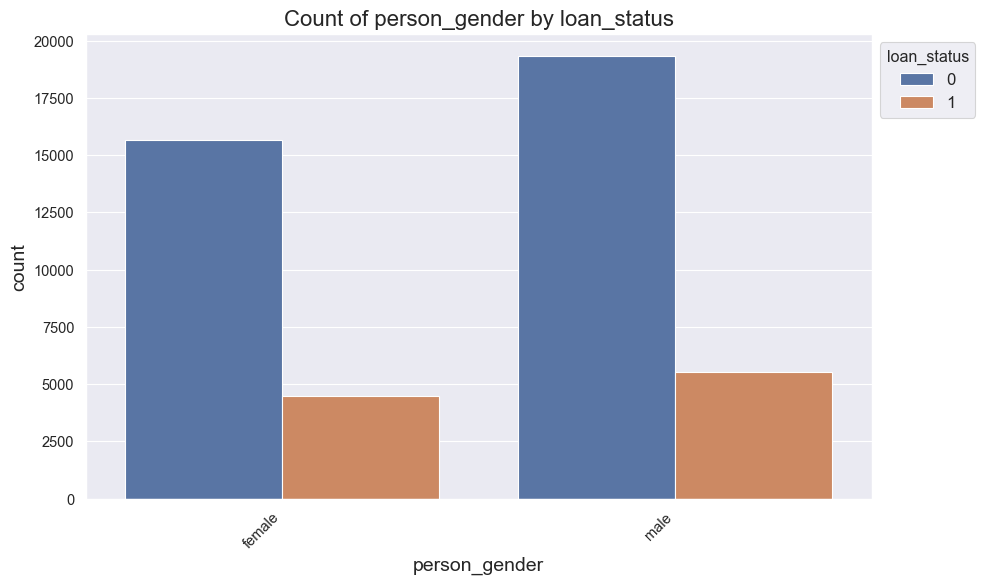

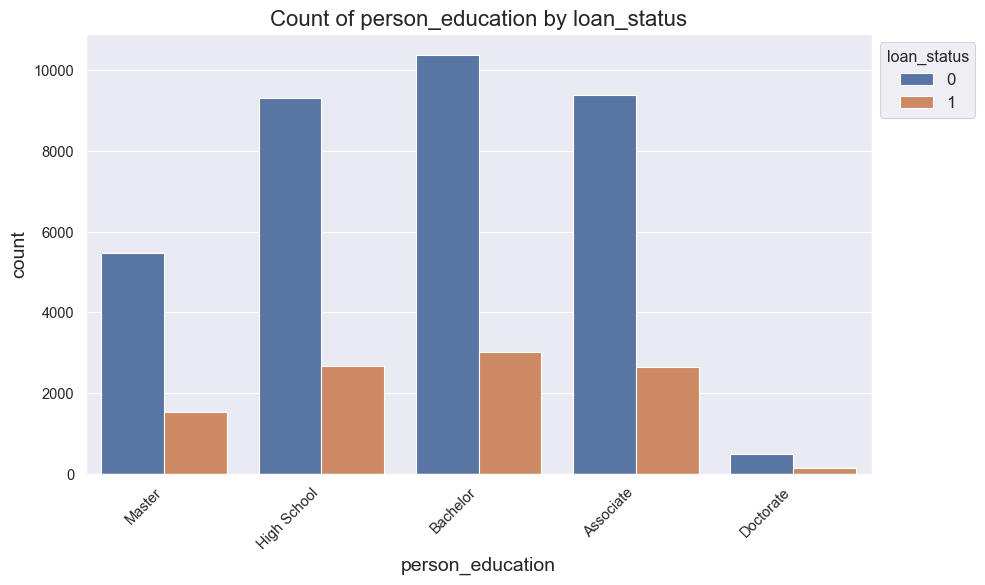

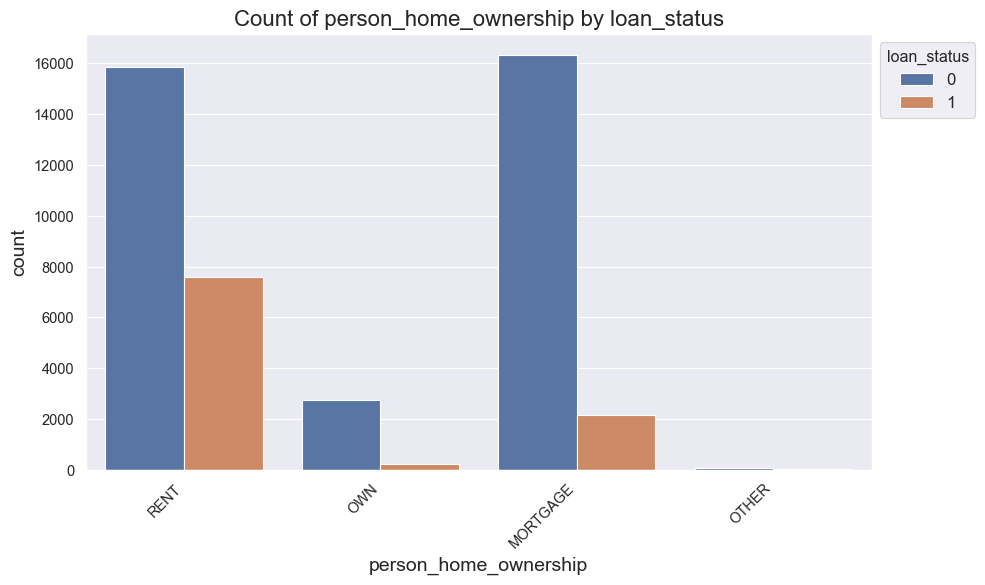

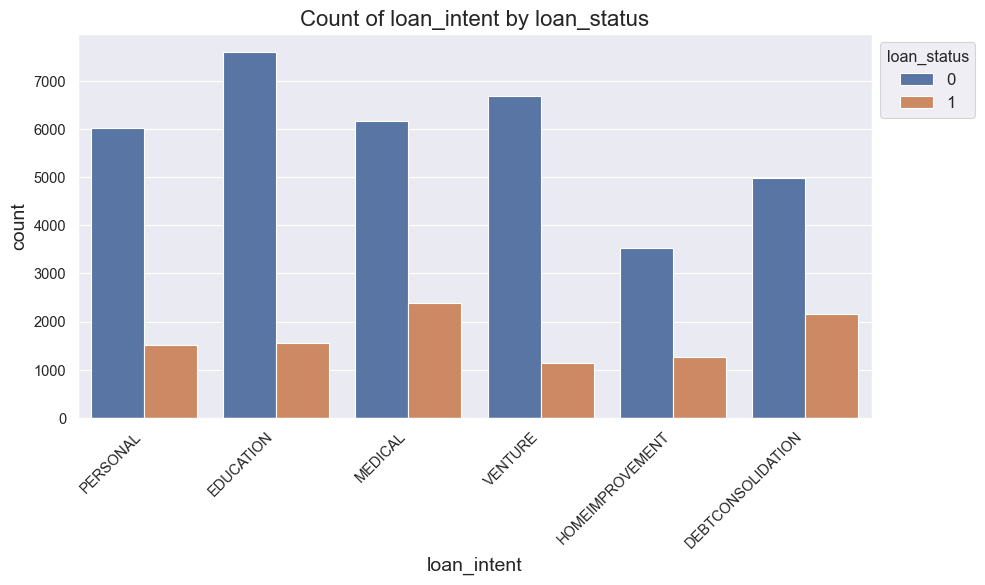

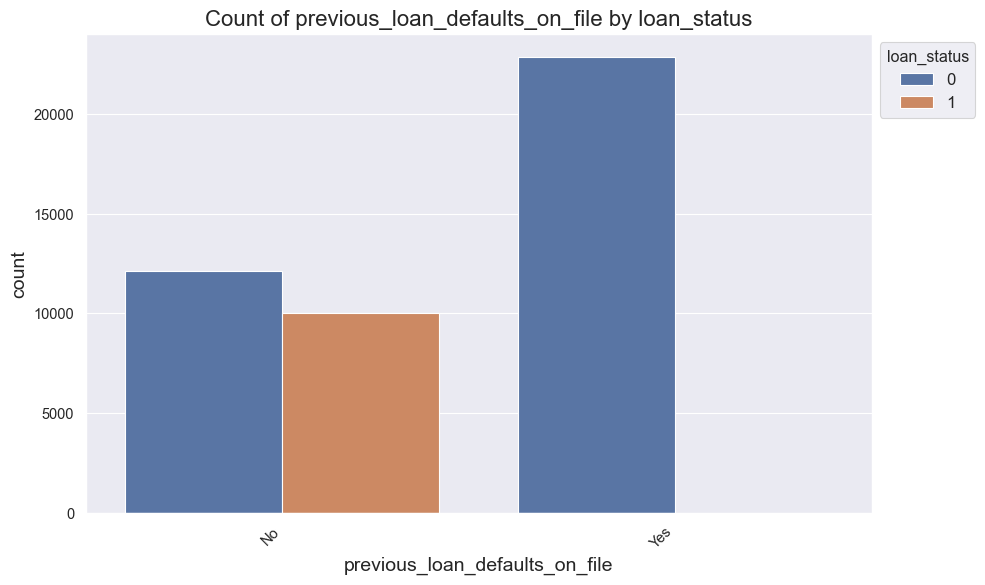

In [12]:
for column in cat_variables:
    plt.figure(figsize=(10, 6))  # Wider figure
    ax = sns.countplot(data=df, x=column, hue=target_variable)

    # Rotate x-labels to avoid overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Move legend and give a clean title
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    plt.title(f'Count of {column} by {target_variable}')
    plt.tight_layout()   # Prevent clipping
    plt.show()

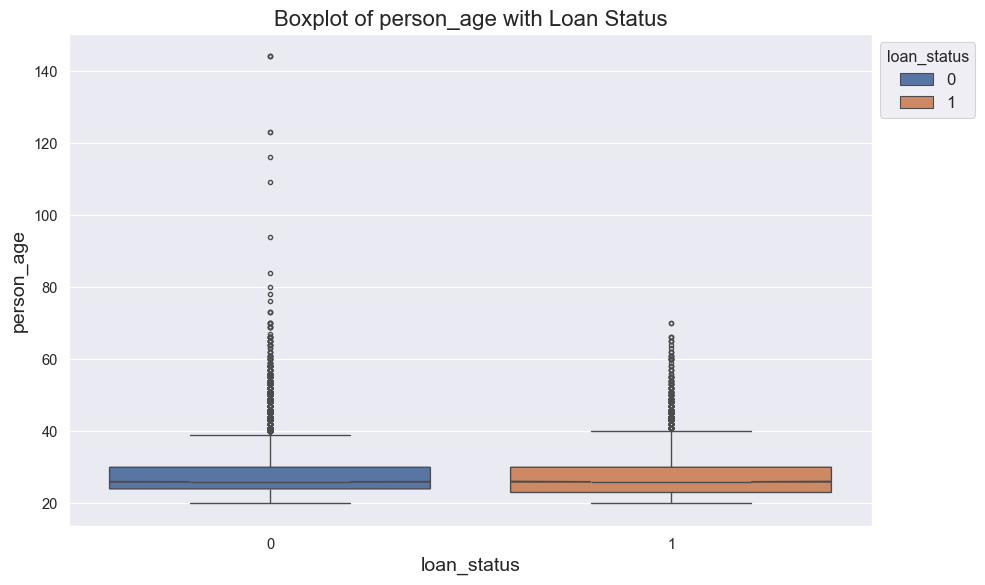

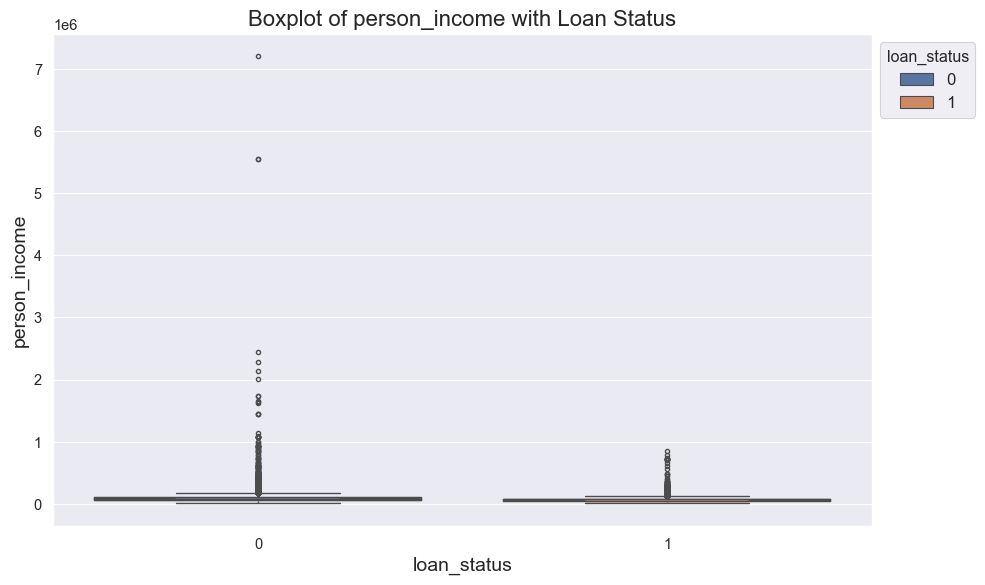

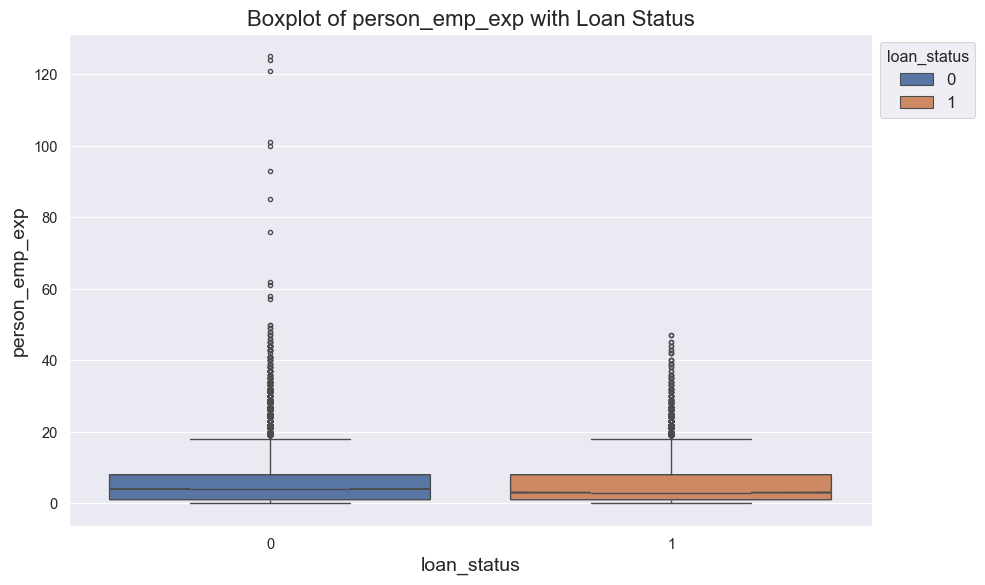

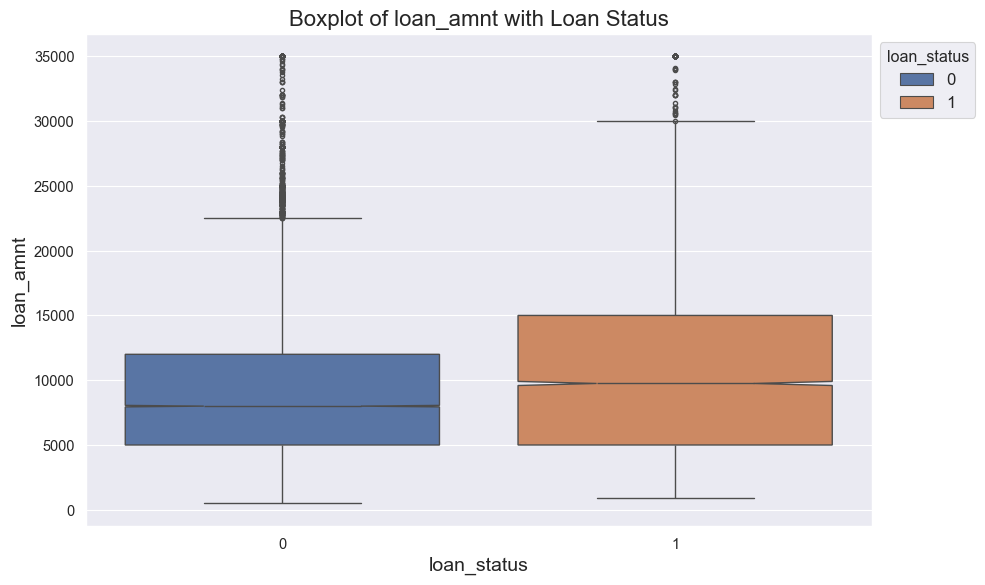

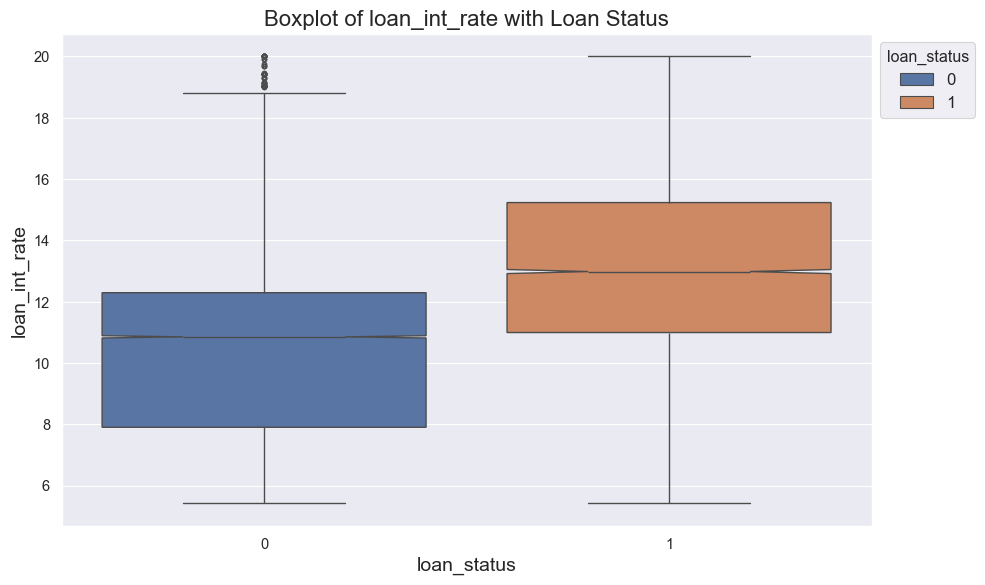

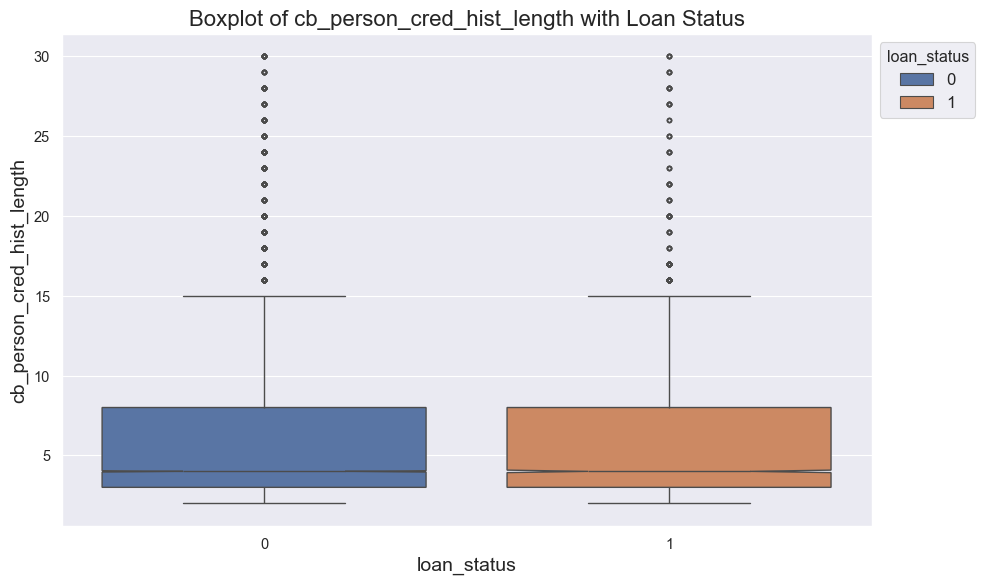

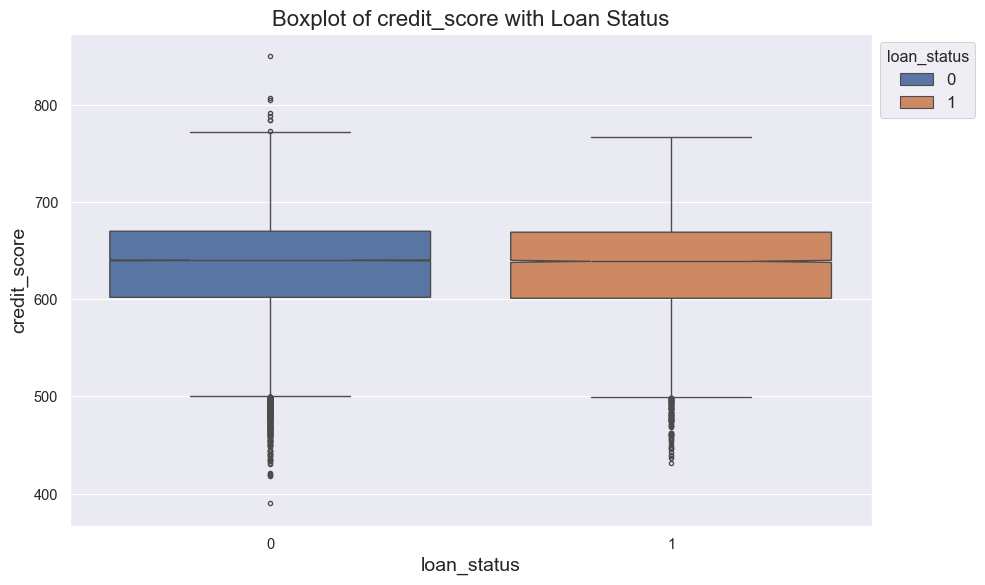

In [13]:
for column in num_variables:
    plt.figure(figsize=(10, 6))  # Wider figure
    ax = sns.boxplot(data=df, y=column, x=target_variable, hue=target_variable, notch=True, fliersize=3)
    # Move legend and give a clean title
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.title(f'Boxplot of {column} with Loan Status')
    plt.tight_layout()   # Prevent clipping
    plt.show()

Loan interest analysis

Interest against loan_amnt, loan_intent, cb_person_cred_hist_length, credit_score, previous_loan_defaults_on_file, person_home_ownership, person_income, person_age, person_gender, person_education

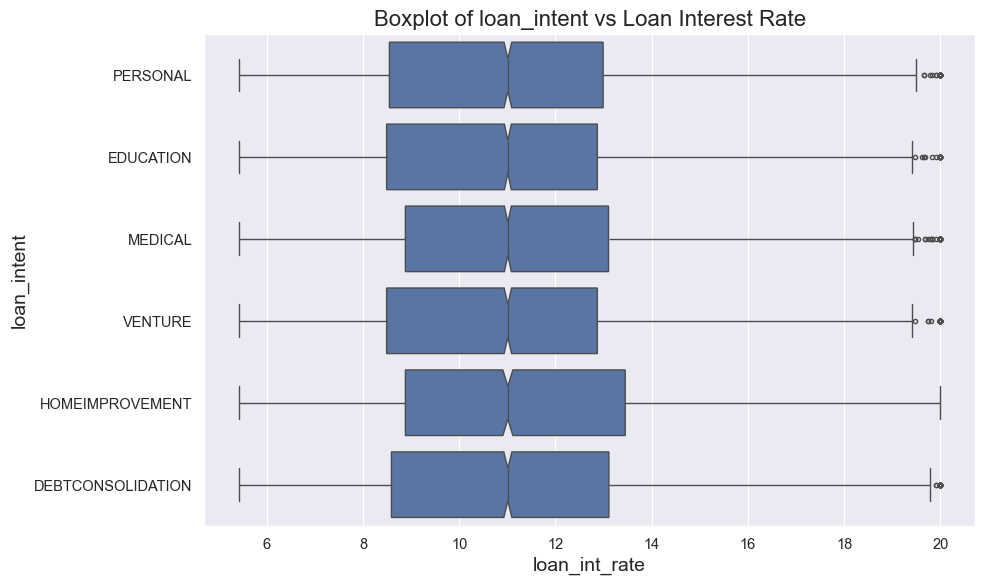

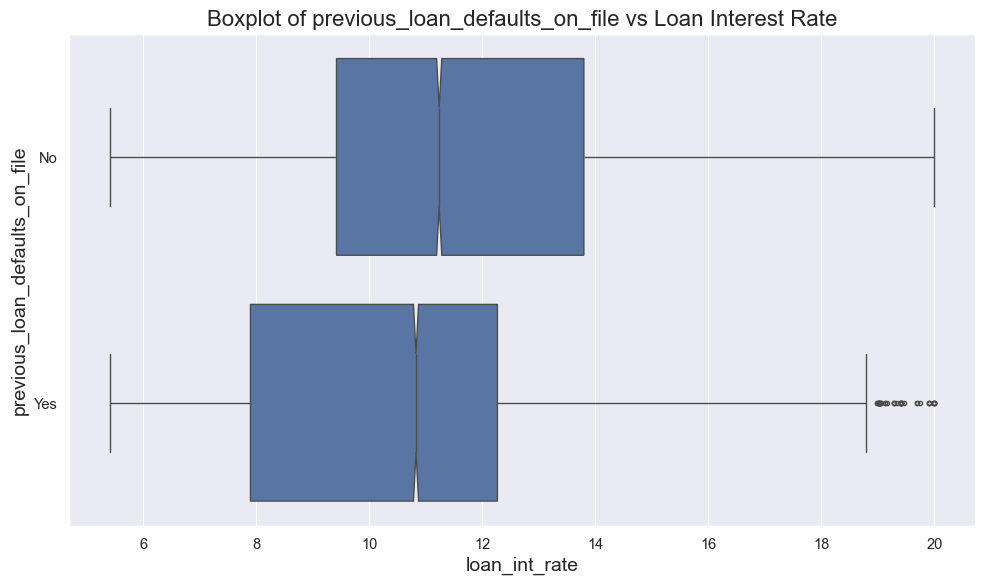

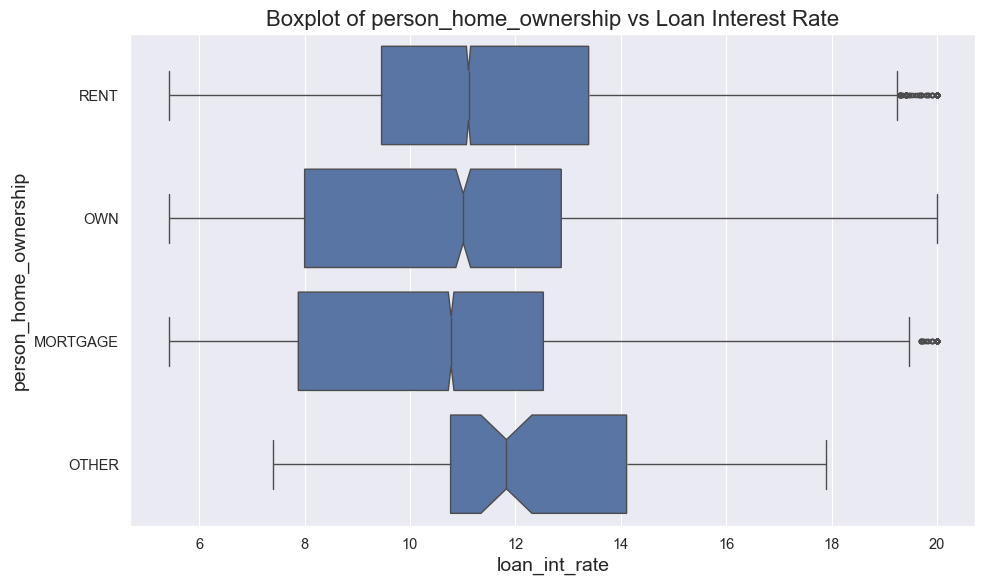

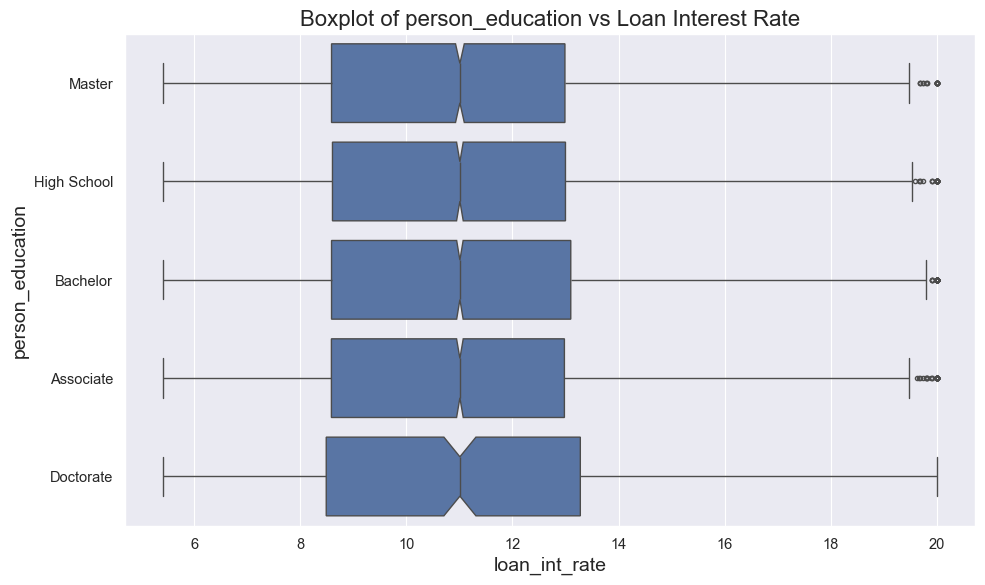

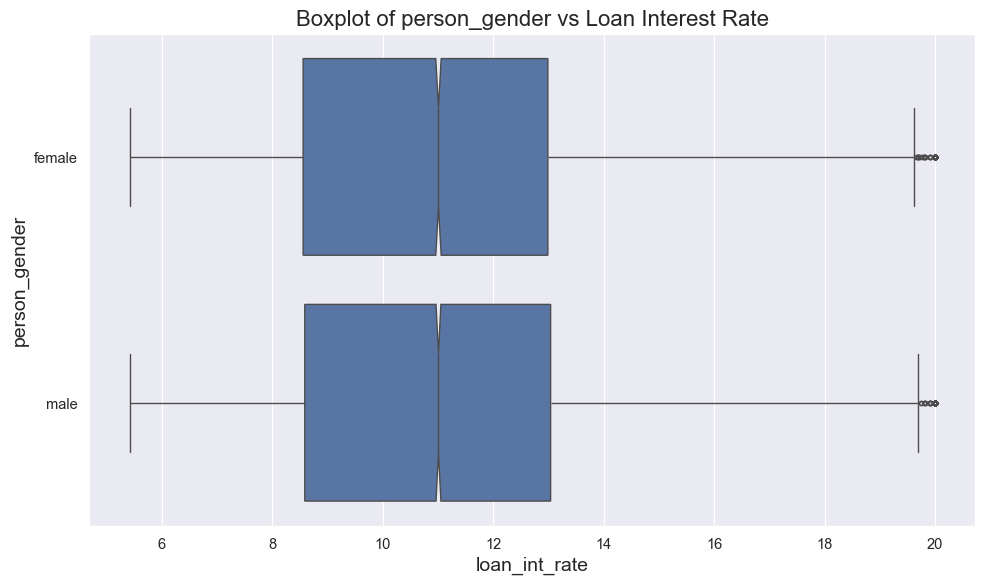

In [25]:
cat_columns_for_interest_analysis = [
    'loan_intent', 'previous_loan_defaults_on_file', 'person_home_ownership',
    'person_education', 'person_gender'
    ]

for col in cat_columns_for_interest_analysis:
    plt.figure(figsize=(10, 6))  # Wider figure
    ax = sns.boxplot(data=df, x='loan_int_rate', y=col, notch=True, fliersize=3)
    plt.title(f'Boxplot of {col} vs Loan Interest Rate')
    plt.tight_layout()   # Prevent clipping
    plt.show()

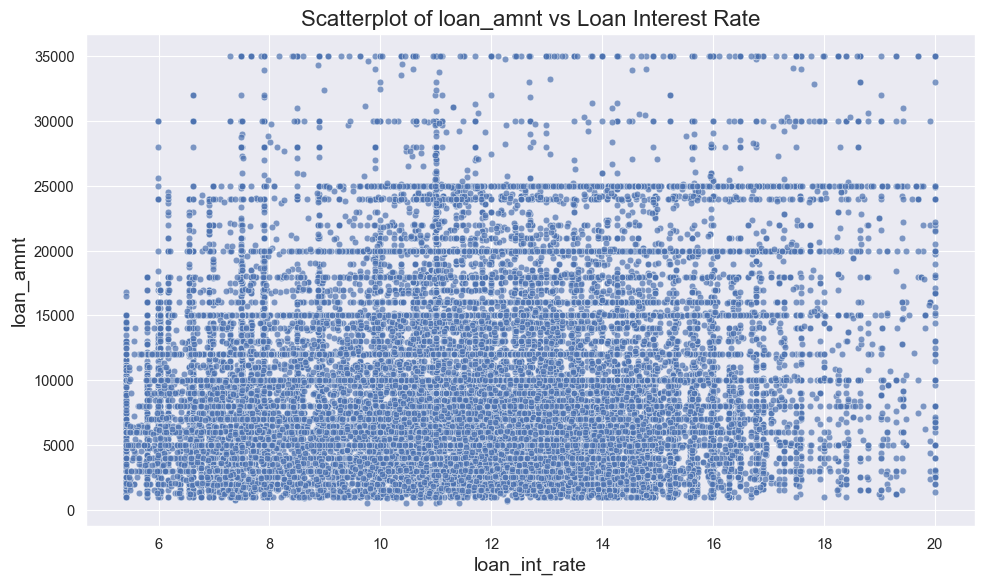

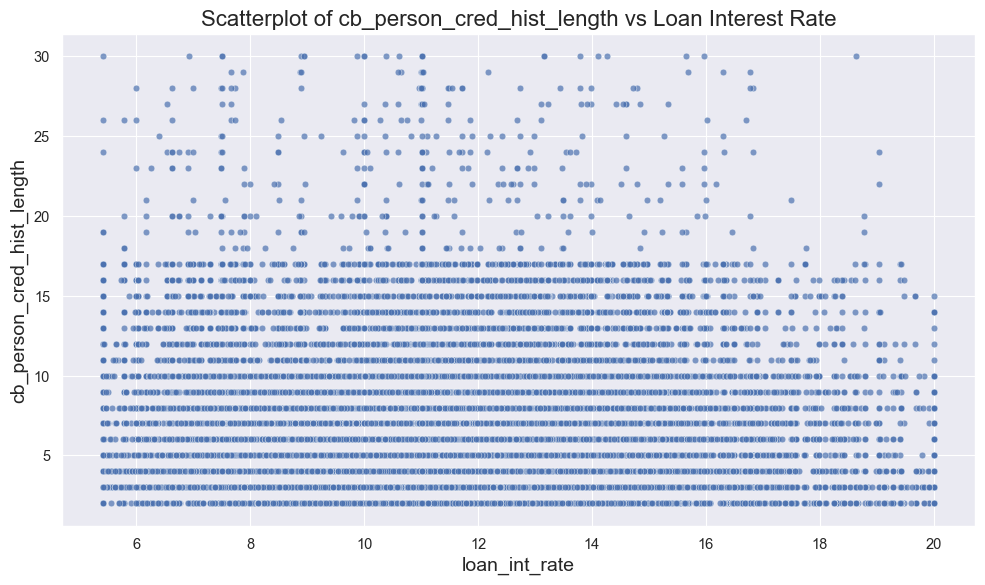

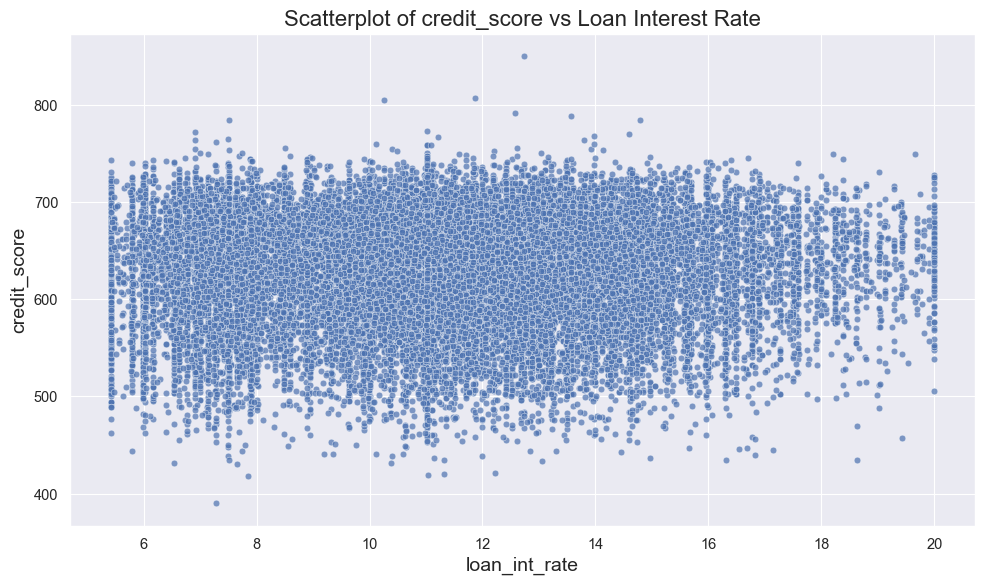

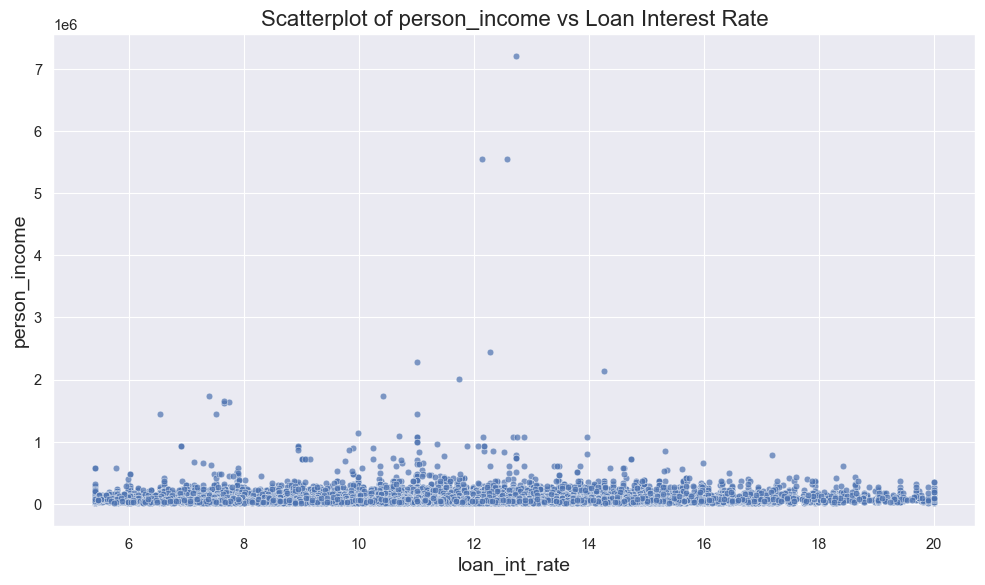

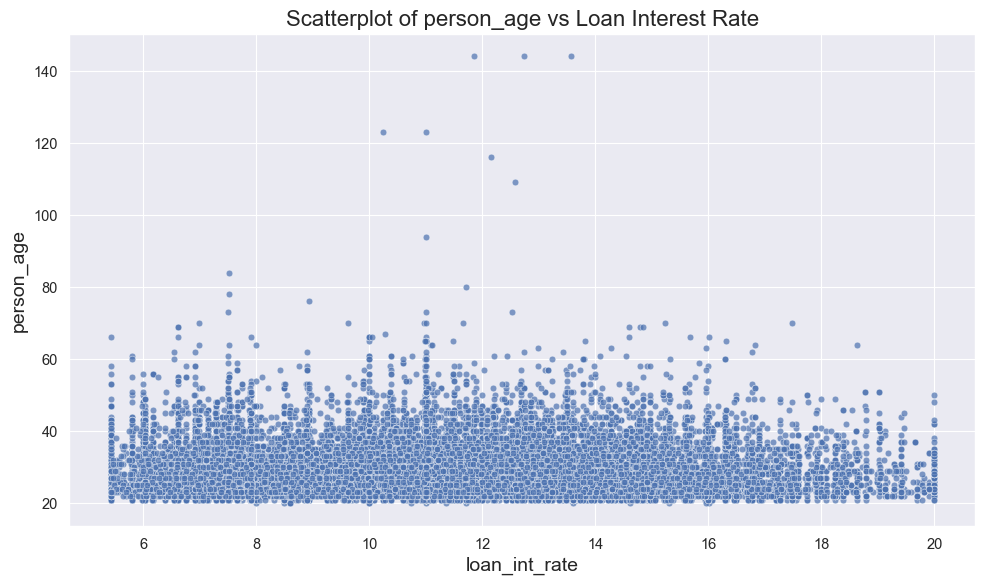

In [23]:
num_columns_for_interest_analysis = [
    'loan_amnt', 'cb_person_cred_hist_length', 'credit_score', 'person_income', 'person_age'
]

for col in num_columns_for_interest_analysis:
    plt.figure(figsize=(10, 6))  # Wider figure
    ax = sns.scatterplot(data=df, x='loan_int_rate', y=col, alpha=0.7)
    plt.title(f'Scatterplot of {col} vs Loan Interest Rate')
    plt.tight_layout()   # Prevent clipping
    plt.show()

Loan amount analysis

income vs loan amount

intent vs loan amount

cb_person_cred_hist_length vs loan amount

age and gender vs loan amount

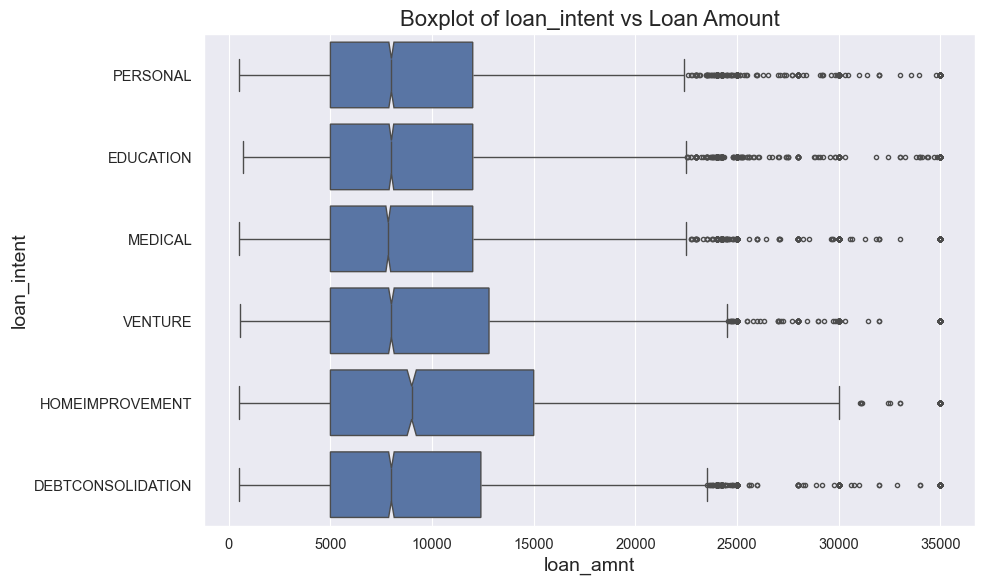

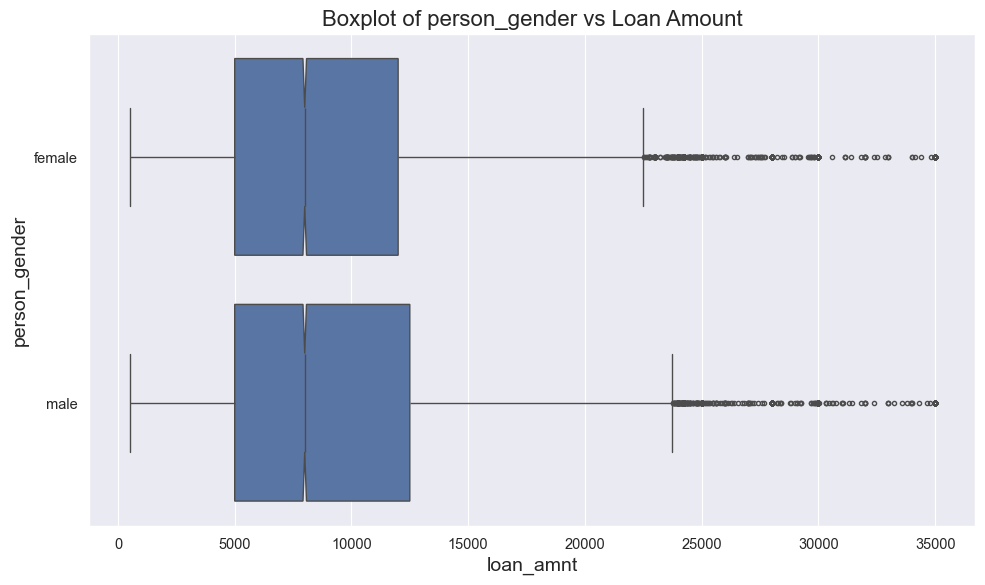

In [26]:
cat_columns_for_amount_analysis = [
    'loan_intent', 'person_gender'
]

for col in cat_columns_for_amount_analysis:
    plt.figure(figsize=(10, 6))  # Wider figure
    ax = sns.boxplot(data=df, x='loan_amnt', y=col, notch=True, fliersize=3)
    plt.title(f'Boxplot of {col} vs Loan Amount')
    plt.tight_layout()   # Prevent clipping
    plt.show()

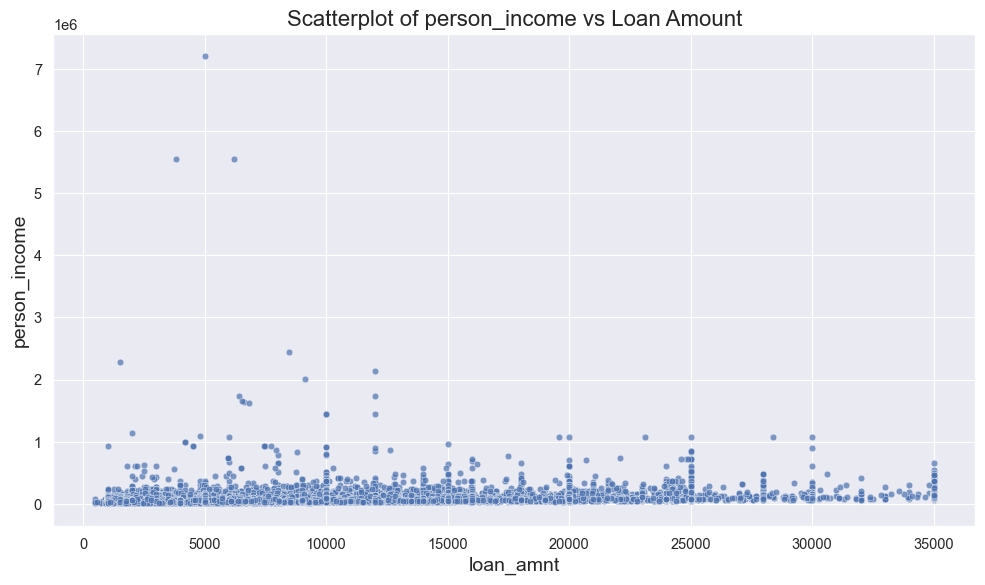

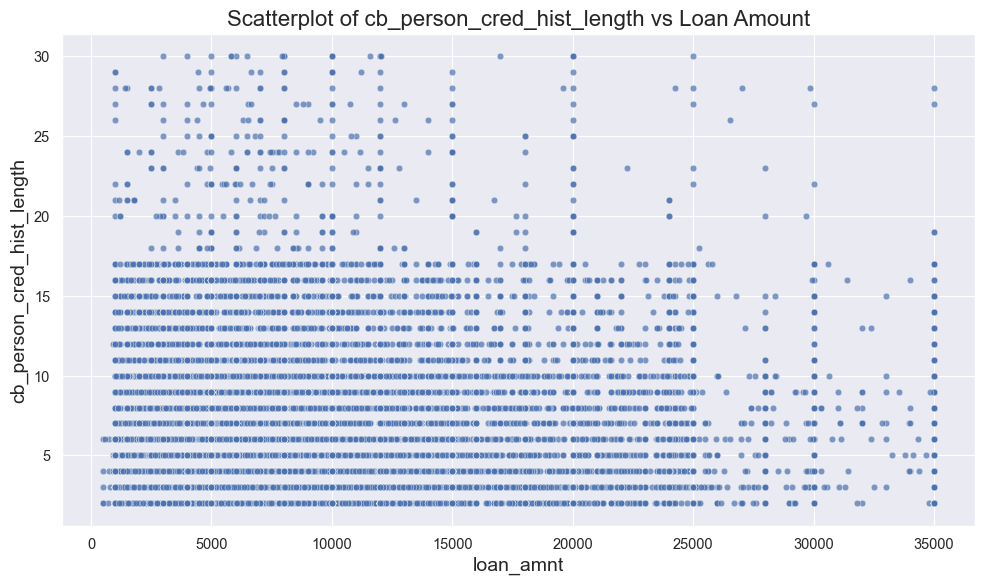

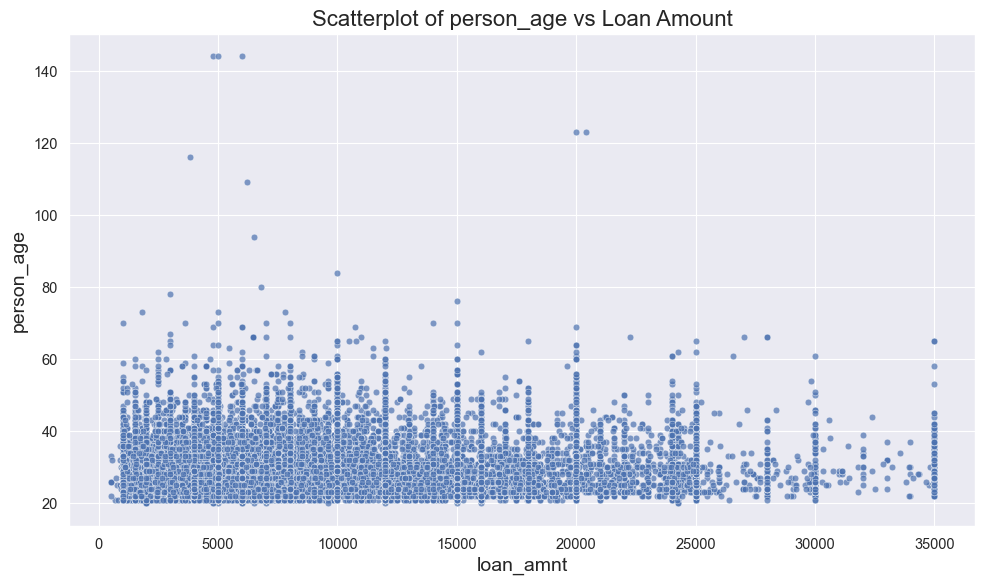

In [27]:
num_columns_for_amount_analysis = [
    'person_income', 'cb_person_cred_hist_length', 'person_age'
]

for col in num_columns_for_amount_analysis:
    plt.figure(figsize=(10, 6))  # Wider figure
    ax = sns.scatterplot(data=df, x='loan_amnt', y=col, alpha=0.7)
    plt.title(f'Scatterplot of {col} vs Loan Amount')
    plt.tight_layout()   # Prevent clipping
    plt.show()

intent analysis

person age vs intent

gender vs intent

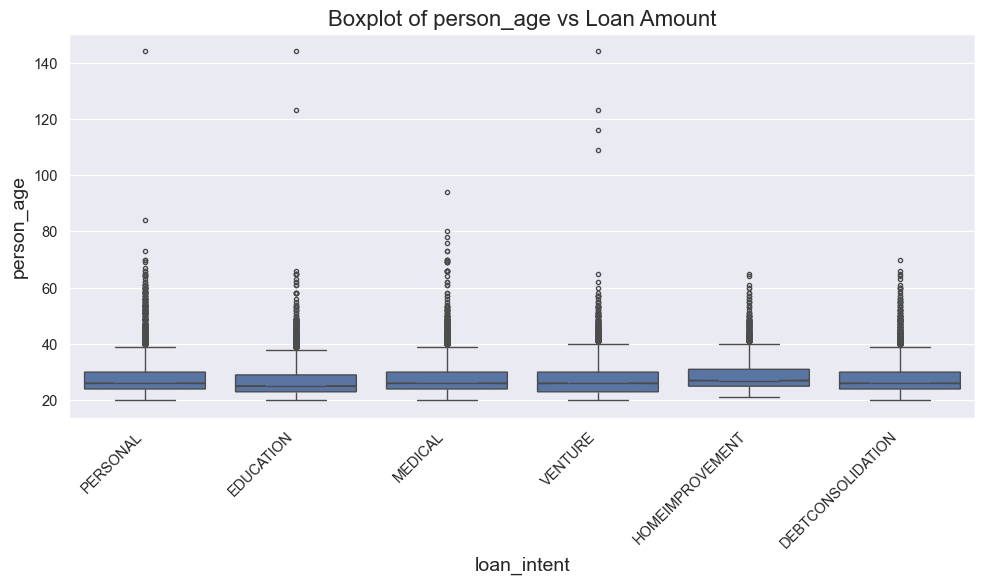

In [29]:
plt.figure(figsize=(10, 6))  # Wider figure
ax = sns.boxplot(data=df, x='loan_intent', y='person_age', notch=True, fliersize=3)
# Rotate x-labels to avoid overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Boxplot of person_age vs Loan Amount')
plt.tight_layout()   # Prevent clipping
plt.show()

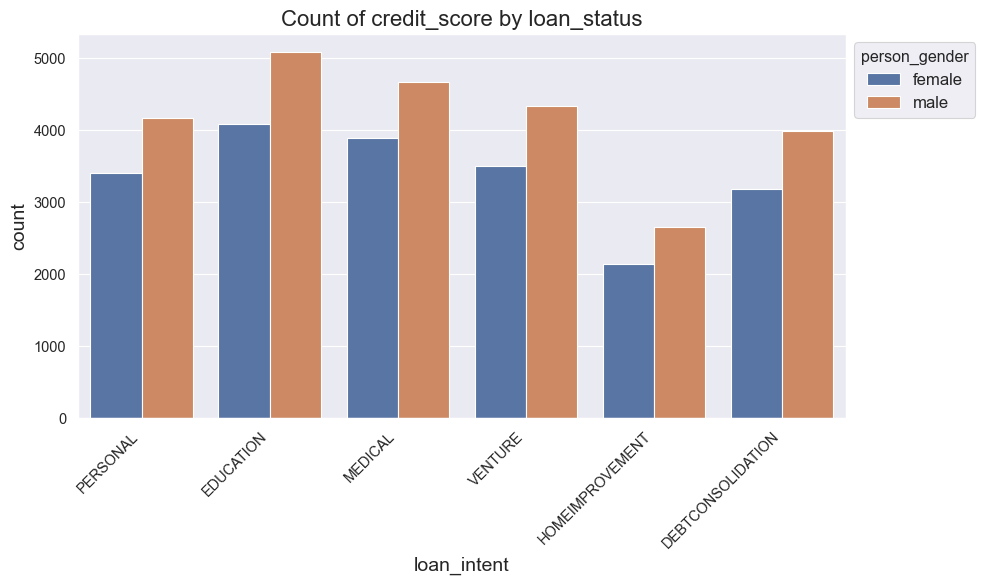

In [ ]:
plt.figure(figsize=(10, 6))  # Wider figure
ax = sns.countplot(data=df, hue='person_gender', x='loan_intent')

# Rotate x-labels to avoid overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Move legend and give a clean title
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.title('Count of loan_intent by person_gender')
plt.tight_layout()   # Prevent clipping
plt.show()

credit score analysis

credit score vs cb_person_cred_hist_length and previous_loan_defaults_on_file

credit score vs loan amount

credit history analysis

cb_person_cred_hist_length vs previous_loan_defaults_on_file and person_home_ownership and gender

In [ ]:
# df[num_variables].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
person_age,45000.00,27.76,6.05,20.00,24.00,26.00,30.00,144.00
person_income,45000.00,80319.05,80422.50,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.00,5.41,6.06,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.00,9583.16,6314.89,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.00,11.01,2.98,5.42,8.59,11.01,12.99,20.00
cb_person_cred_hist_length,45000.00,5.87,3.88,2.00,3.00,4.00,8.00,30.00
credit_score,45000.00,632.61,50.44,390.00,601.00,640.00,670.00,850.00


In [ ]:
# high_age_count = (df['person_age'] > 100).sum()
# print(high_age_count)

# # Remove rows with age greater than 100
# df = df[df['person_age'] <= 100]

7


Although `DOCTORATE` category in `person_education` and `OTHER` category in `person_home_ownership` have significantly less values compared to other values in their respective category, they still have some data and might be useful in predicting edge cases.

Now we remove rows which have more than 1 column marked as outlier.

In [ ]:
# df0 = df.copy()
# before_rows = df0.shape[0]

# # build a counter for rows that are outliers in ANY column
# outlier_mask = pd.Series(0, index=df0.index)

# for col in num_variables:
#     Q1 = df0[col].quantile(0.25)
#     Q3 = df0[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
#     outlier_mask += ((df0[col] < lower) | (df0[col] > upper)).astype(int)

# df_clean = df0[outlier_mask <= 1].copy()
# removed = before_rows - df_clean.shape[0]
# print(f"{removed} rows removed as outliers (flagged in more than one column).")

2462 rows removed as outliers (flagged in more than one column).


Now we winsorize outliers in the data. This [article](https://medium.com/@olamidequzeem91/winsorization-an-act-of-accommodating-outliers-22ced87d03fb) does a great job of explaining it.

In [ ]:
# df_winsorized = df_clean.copy()

# for column in num_variables:
#     Q1 = df_clean[column].quantile(0.25)
#     Q3 = df_clean[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     df_winsorized[column] = df_winsorized[column].clip(lower_bound, upper_bound)

In [ ]:
# df_winsorized[num_variables].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
person_age,42531.00,26.89,4.33,20.00,23.00,26.00,29.00,38.00
person_income,42531.00,73857.93,36011.58,8000.00,46728.00,66680.00,93234.50,162994.25
person_emp_exp,42531.00,4.54,4.35,0.00,1.00,3.00,7.00,16.00
loan_amnt,42531.00,9179.64,5580.31,500.00,5000.00,8000.00,12000.00,22500.00
loan_int_rate,42531.00,10.98,2.96,5.42,8.57,11.01,12.99,19.62
cb_person_cred_hist_length,42531.00,5.34,3.00,2.00,3.00,4.00,7.00,13.00
credit_score,42531.00,631.71,49.34,498.00,600.00,639.00,668.00,768.00


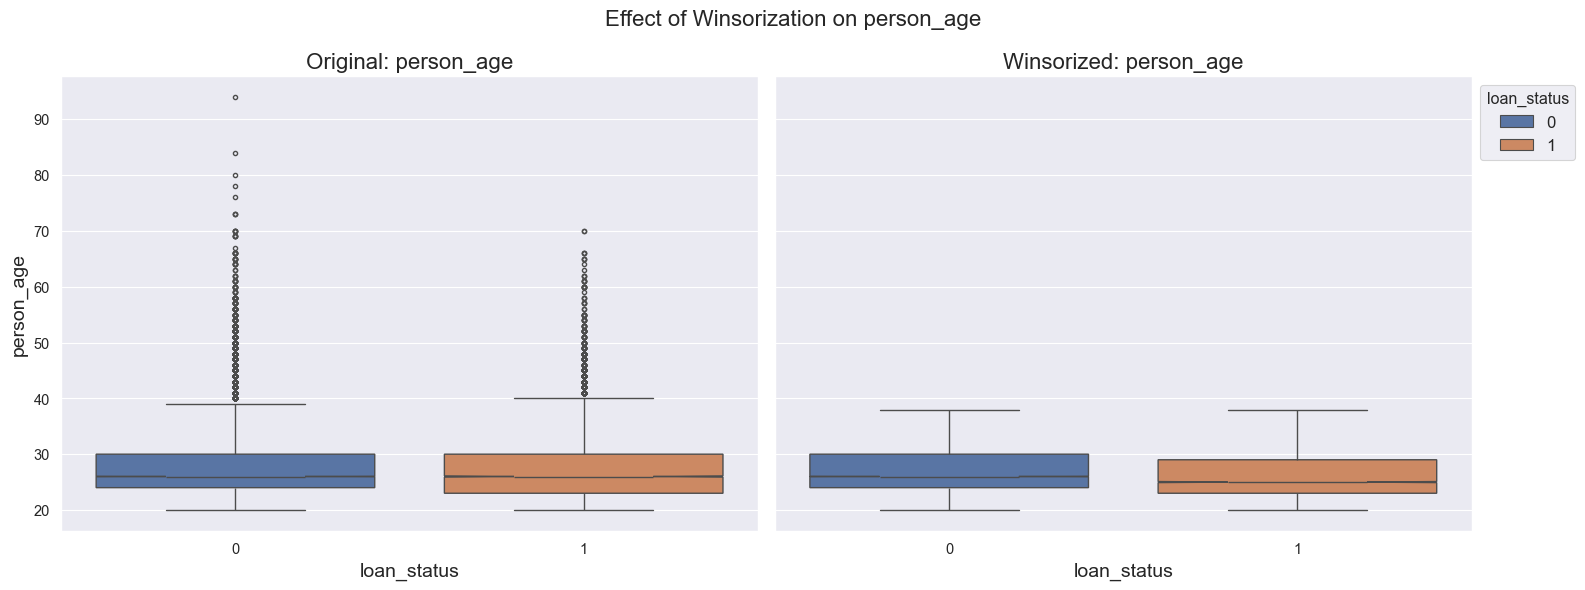

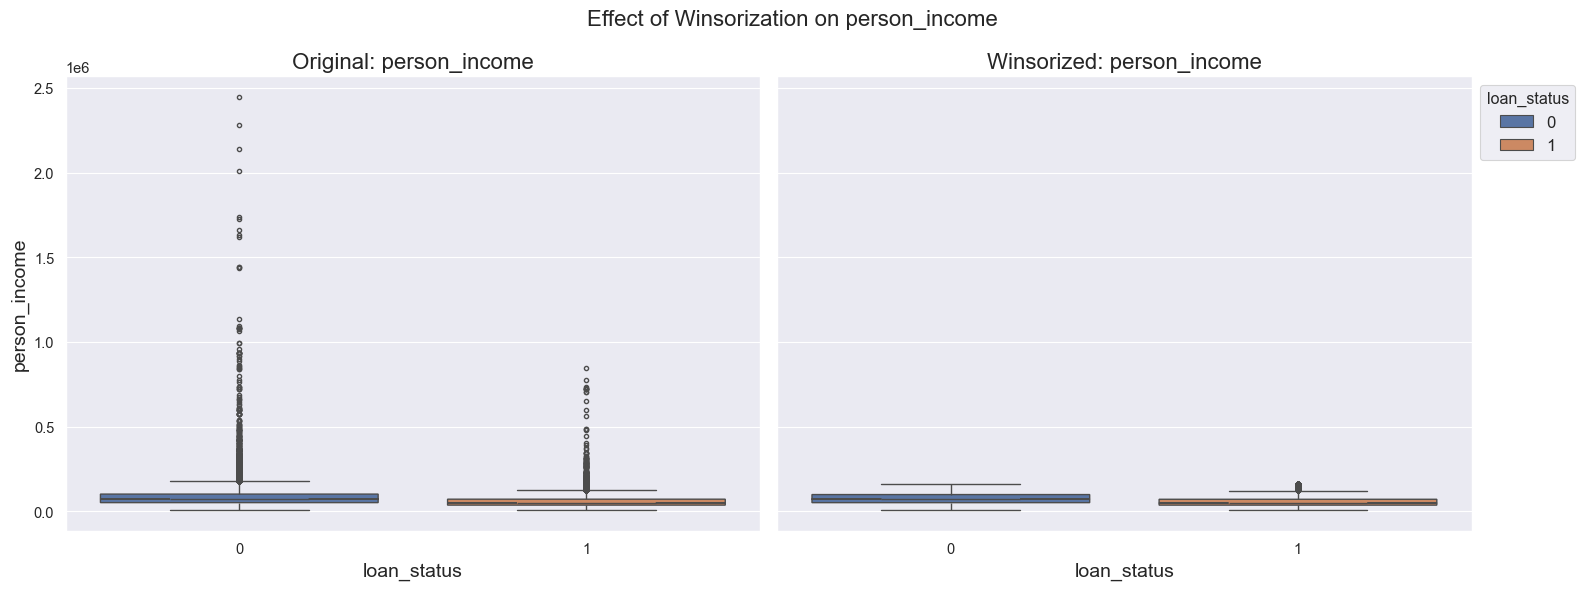

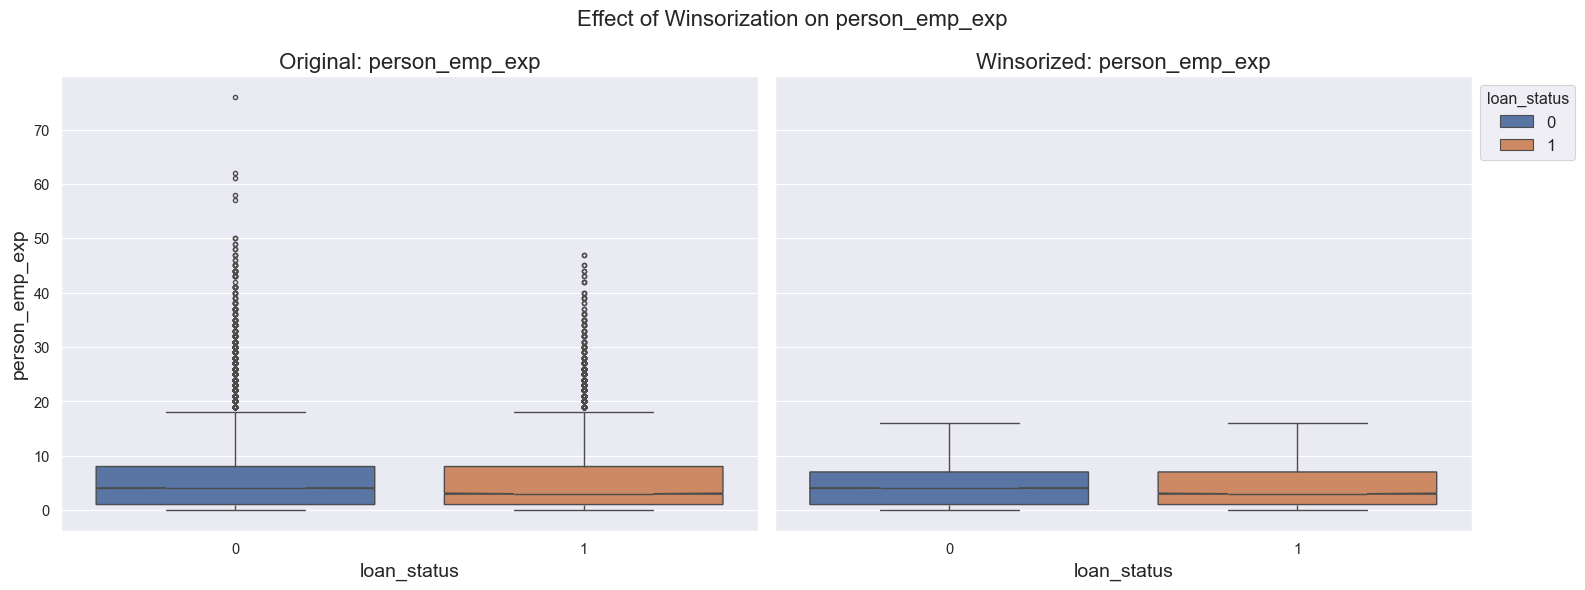

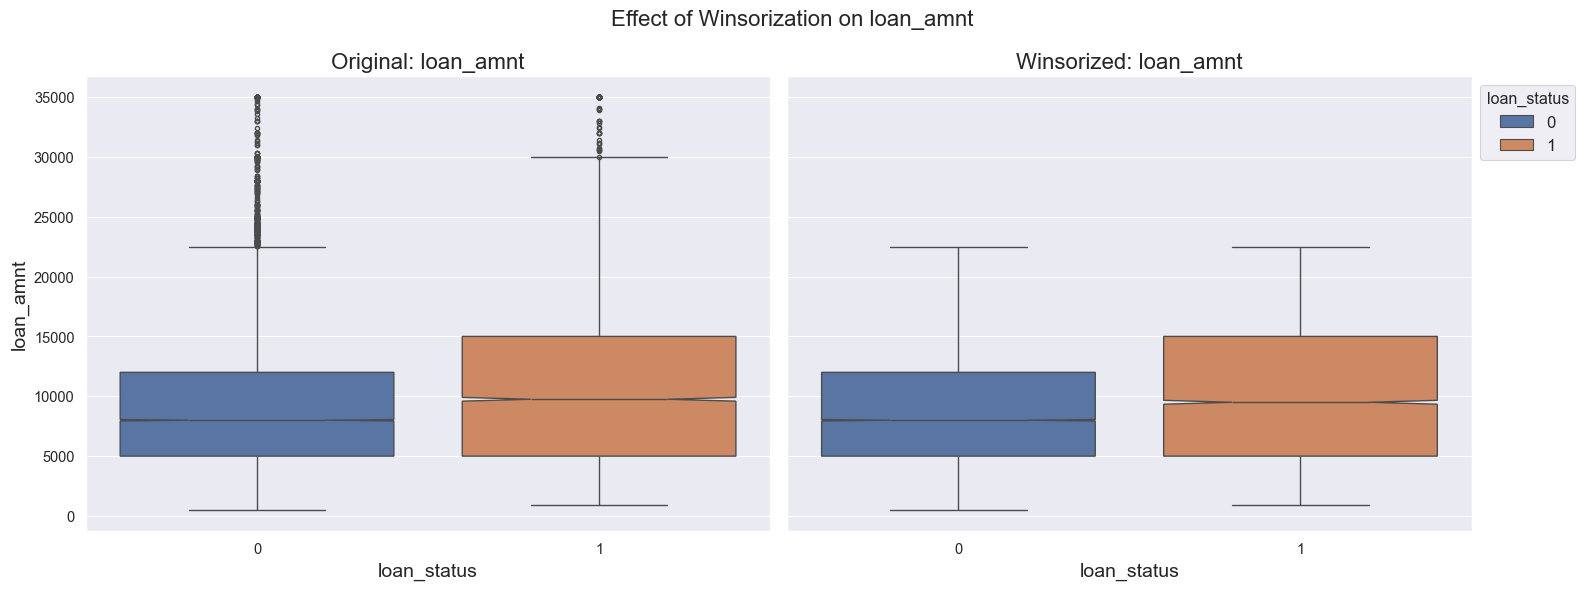

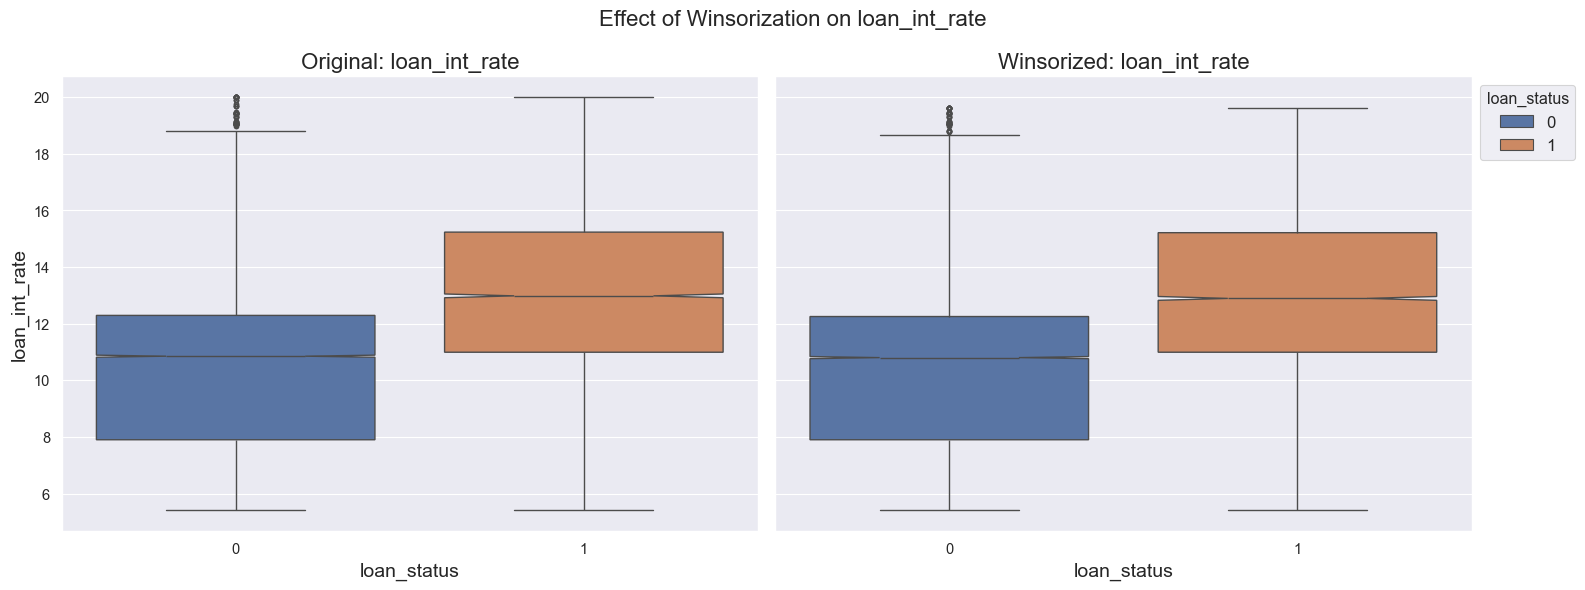

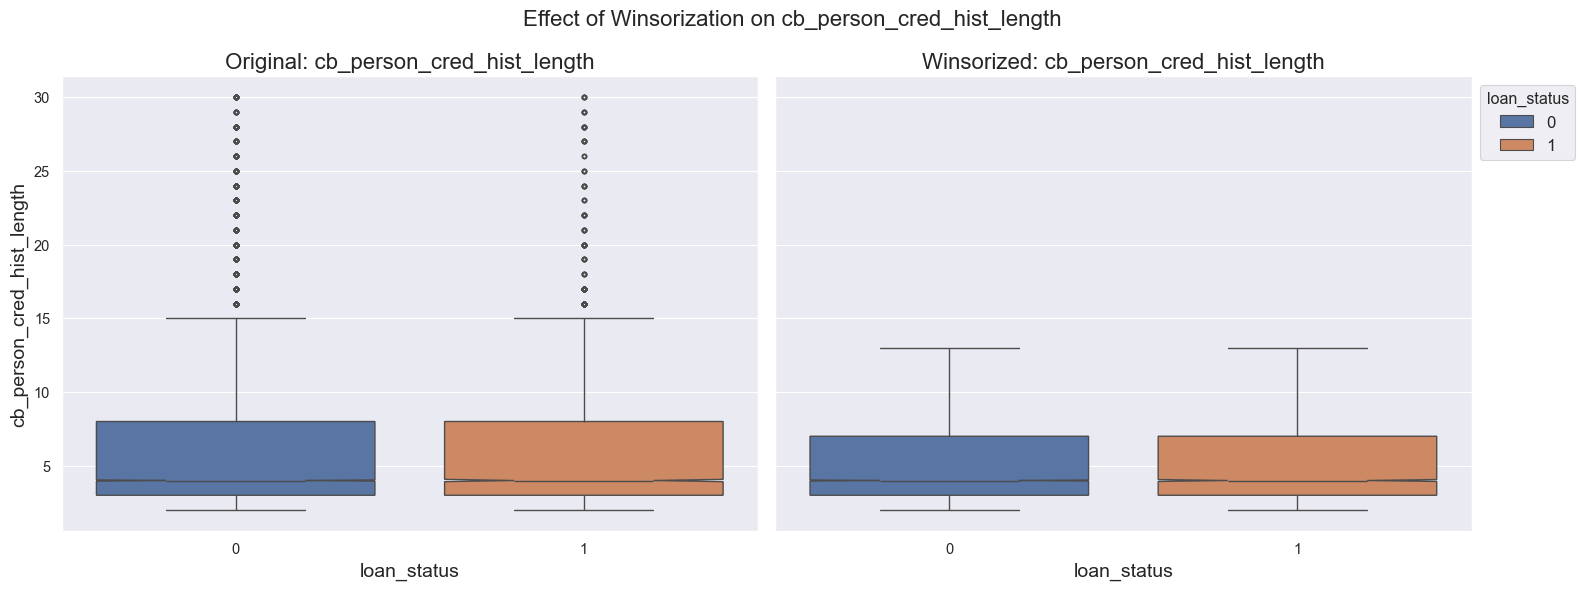

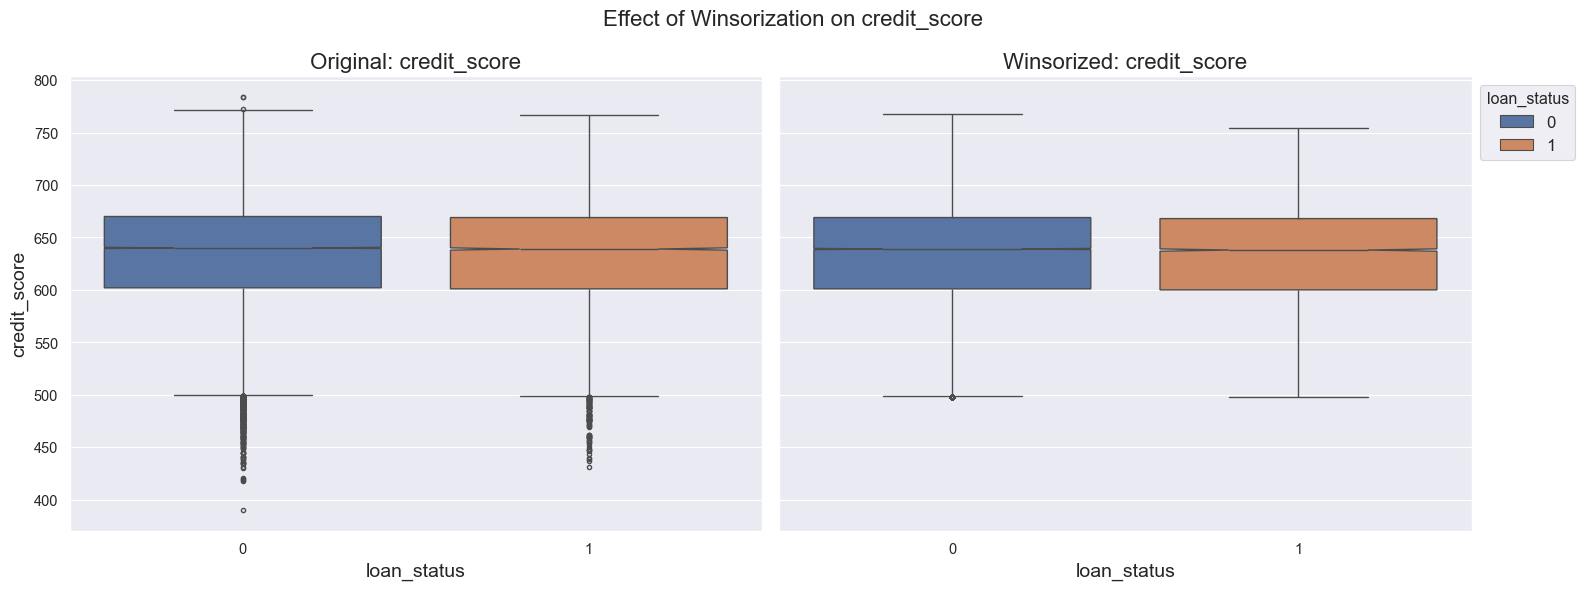

In [ ]:
# for column in num_variables:
#     fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

#     # Original
#     sns.boxplot(
#         data=df,
#         x=target_variable,
#         y=column,
#         hue=target_variable,
#         notch=True,
#         fliersize=3,
#         ax=axes[0]
#     )
#     axes[0].set_title(f'Original: {column}')
#     axes[0].legend_.remove()

#     # Winsorized
#     sns.boxplot(
#         data=df_winsorized,
#         x=target_variable,
#         y=column,
#         hue=target_variable,
#         notch=True,
#         fliersize=3,
#         ax=axes[1]
#     )
#     axes[1].set_title(f'Winsorized: {column}')
#     sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1, 1))

#     fig.suptitle(f'Effect of Winsorization on {column}', fontsize=16)
#     plt.tight_layout()
#     plt.show()
